# Variance Reduction Techniques in Monte Carlo Simulation

This notebook covers three fundamental variance reduction methods that dramatically improve the efficiency of Monte Carlo estimators:

1. **Antithetic Variates** — exploit negative correlation between paired samples
2. **Importance Sampling** — change the probability measure to focus on important regions
3. **Control Variates** — use a correlated variable with known expectation to reduce noise

For each method, we provide the mathematical justification, Python implementation, and empirical variance comparison.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from math import exp, sqrt, erf, log

np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

## 1. Antithetic Variates

Given a uniform random variable $U \sim \text{Uniform}(0,1)$, the antithetic pair is $1-U$. These are perfectly negatively correlated.

For an estimator $I = \mathbb{E}[f(X)]$, the antithetic estimator is:

$$\hat{I}_{\text{anti}} = \frac{1}{N} \sum_{i=1}^{N/2} \frac{f(X_i) + f(X_i')}{2}$$

If $f$ is monotone, then $\text{Cov}(f(X), f(X')) < 0$, and:

$$\text{Var}(\hat{I}_{\text{anti}}) = \frac{1}{2N}\left(\text{Var}(f(X)) + \text{Cov}(f(X), f(X'))\right) < \frac{1}{2N}\text{Var}(f(X))$$

**When it works best:** Monotone integrands and symmetric distributions (e.g., option pricing with normal random variables).

Antithetic Variates for integral of exp(x) on [0,1]
True value:        1.718282
Standard var:      2.222070e-04
Antithetic var:    7.082530e-06
Reduction ratio:   31.37x


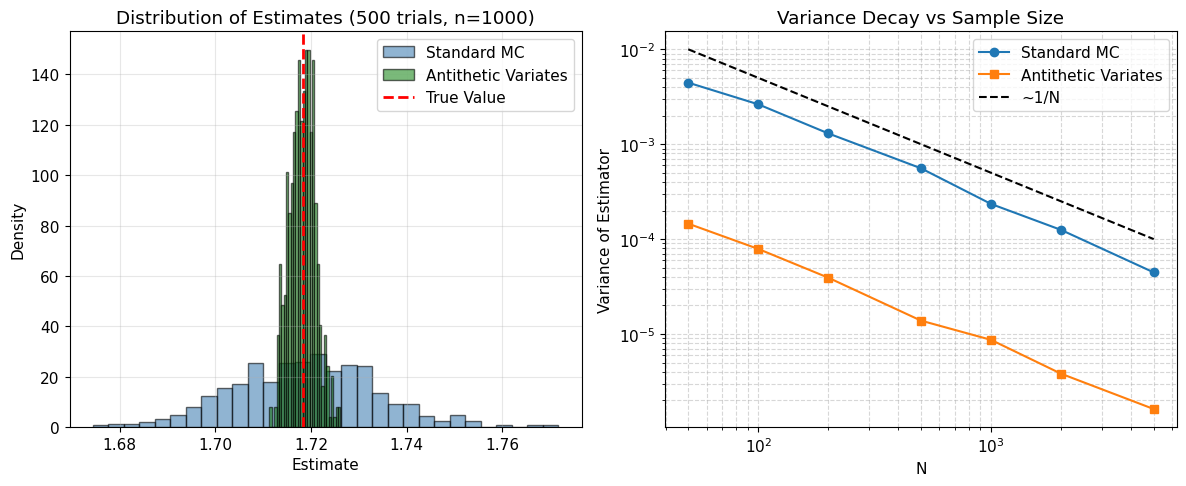

In [3]:
# --- Antithetic Variates ---

def mc_standard_integral(f, n, a=0.0, b=1.0):
    x = np.random.uniform(a, b, n)
    return (b - a) * np.mean(f(x))

def mc_antithetic_integral(f, n, a=0.0, b=1.0):
    n = n // 2
    u = np.random.uniform(0.0, 1.0, n)
    x1 = a + u * (b - a)
    x2 = a + (1.0 - u) * (b - a)
    y = 0.5 * (f(x1) + f(x2))
    return (b - a) * np.mean(y)

# Test function: f(x) = exp(x) on [0,1]
f_exp = lambda x: np.exp(x)
true_val = exp(1) - 1

n_trials = 500
n = 1000
est_std = [mc_standard_integral(f_exp, n) for _ in range(n_trials)]
est_anti = [mc_antithetic_integral(f_exp, n) for _ in range(n_trials)]

var_std = np.var(est_std, ddof=1)
var_anti = np.var(est_anti, ddof=1)

print("Antithetic Variates for integral of exp(x) on [0,1]")
print("True value:        {:.6f}".format(true_val))
print("Standard var:      {:.6e}".format(var_std))
print("Antithetic var:    {:.6e}".format(var_anti))
print("Reduction ratio:   {:.2f}x".format(var_std / var_anti))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(est_std, bins=30, density=True, alpha=0.6, color='steelblue', edgecolor='black', label='Standard MC')
axes[0].hist(est_anti, bins=30, density=True, alpha=0.6, color='forestgreen', edgecolor='black', label='Antithetic Variates')
axes[0].axvline(true_val, color='red', linestyle='--', lw=2, label='True Value')
axes[0].set_title('Distribution of Estimates ({} trials, n={})'.format(n_trials, n))
axes[0].set_xlabel('Estimate')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

N_list = np.array([50, 100, 200, 500, 1000, 2000, 5000])
var_std_N = []
var_anti_N = []
for N in N_list:
    vals_s = [mc_standard_integral(f_exp, N) for _ in range(200)]
    vals_a = [mc_antithetic_integral(f_exp, N) for _ in range(200)]
    var_std_N.append(np.var(vals_s, ddof=1))
    var_anti_N.append(np.var(vals_a, ddof=1))

axes[1].loglog(N_list, var_std_N, 'o-', label='Standard MC')
axes[1].loglog(N_list, var_anti_N, 's-', label='Antithetic Variates')
axes[1].loglog(N_list, 0.5 / N_list, 'k--', label='~1/N')
axes[1].set_title('Variance Decay vs Sample Size')
axes[1].set_xlabel('N')
axes[1].set_ylabel('Variance of Estimator')
axes[1].legend()
axes[1].grid(True, which='both', ls='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 2. Importance Sampling

Importance sampling changes the sampling distribution to concentrate samples where the integrand is large (or where rare events occur).

For an expectation under target density $p(x)$:

$$I = \mathbb{E}_p[h(X)] = \int h(x) p(x) \, dx = \int h(x) \frac{p(x)}{q(x)} q(x) \, dx = \mathbb{E}_q\left[h(X) \frac{p(X)}{q(X)}\right]$$

The **importance weight** is $w(x) = p(x)/q(x)$. We sample $X_i \sim q$ and compute:

$$\hat{I}_{\text{IS}} = \frac{1}{N} \sum_{i=1}^N h(X_i) w(X_i)$$

**Application here:** Estimating the rare-event tail probability $P(Z > 3)$ for $Z \sim \mathcal{N}(0,1)$. Standard MC wastes almost all samples; we use a shifted normal $\mathcal{N}(3.5, 1)$ as the proposal.


Importance Sampling for P(Z > 3)
True probability:    1.349898e-03
Standard MC mean:    1.332200e-03
IS mean:             1.347168e-03
Standard MC var:     2.674706e-07
IS var:              1.264281e-09
Reduction ratio:     211.6x


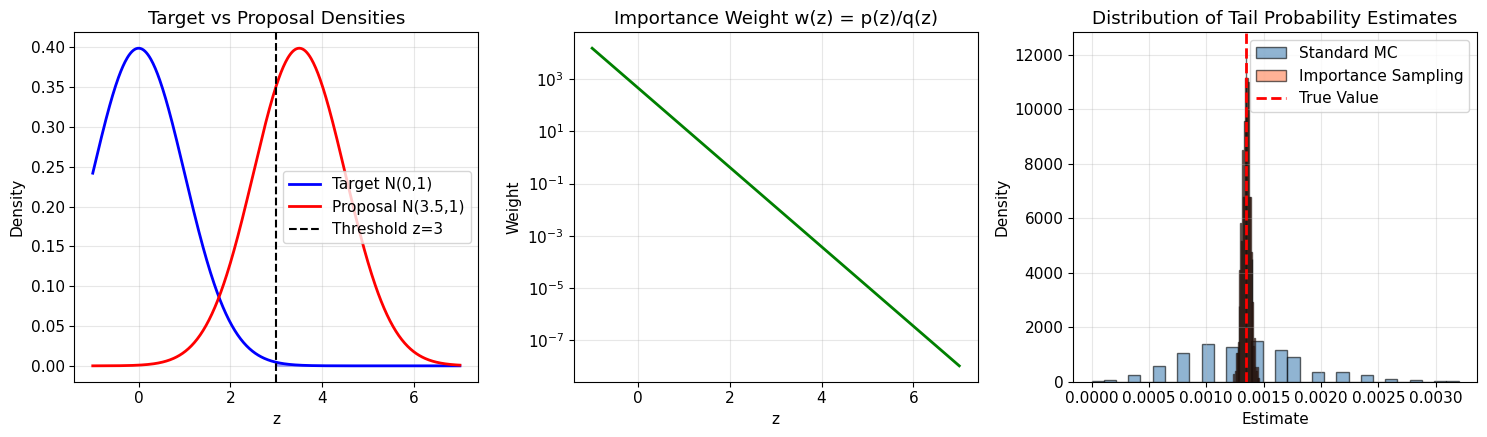

In [4]:
# --- Importance Sampling ---
# Target: P(Z > 3) under Z ~ N(0,1)

true_tail = 0.5 * (1.0 - erf(3.0 / sqrt(2.0)))

def tail_standard(n):
    Z = np.random.standard_normal(n)
    return np.mean(Z > 3.0)

def tail_is(n, mu=3.5):
    Y = np.random.normal(mu, 1.0, n)
    weights = np.exp(0.5 * mu**2 - mu * Y)
    return np.mean((Y > 3.0) * weights)

n = 5000
n_trials = 1000

est_std_tail = [tail_standard(n) for _ in range(n_trials)]
est_is_tail = [tail_is(n, mu=3.5) for _ in range(n_trials)]

var_std_tail = np.var(est_std_tail, ddof=1)
var_is_tail = np.var(est_is_tail, ddof=1)

print("Importance Sampling for P(Z > 3)")
print("True probability:    {:.6e}".format(true_tail))
print("Standard MC mean:    {:.6e}".format(np.mean(est_std_tail)))
print("IS mean:             {:.6e}".format(np.mean(est_is_tail)))
print("Standard MC var:     {:.6e}".format(var_std_tail))
print("IS var:              {:.6e}".format(var_is_tail))
print("Reduction ratio:     {:.1f}x".format(var_std_tail / var_is_tail))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

x = np.linspace(-1, 7, 500)
target_pdf = (1.0 / sqrt(2.0 * np.pi)) * np.exp(-0.5 * x**2)
proposal_pdf = (1.0 / sqrt(2.0 * np.pi)) * np.exp(-0.5 * (x - 3.5)**2)

axes[0].plot(x, target_pdf, 'b-', lw=2, label='Target N(0,1)')
axes[0].plot(x, proposal_pdf, 'r-', lw=2, label='Proposal N(3.5,1)')
axes[0].axvline(3.0, color='black', linestyle='--', label='Threshold z=3')
axes[0].fill_between(x, 0, target_pdf, where=(x > 3), alpha=0.3, color='blue')
axes[0].set_title('Target vs Proposal Densities')
axes[0].set_xlabel('z')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

weights_plot = np.exp(0.5 * 3.5**2 - 3.5 * x)
axes[1].plot(x, weights_plot, 'g-', lw=2)
axes[1].set_title('Importance Weight w(z) = p(z)/q(z)')
axes[1].set_xlabel('z')
axes[1].set_ylabel('Weight')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)

axes[2].hist(est_std_tail, bins=30, density=True, alpha=0.6, color='steelblue', edgecolor='black', label='Standard MC')
axes[2].hist(est_is_tail, bins=30, density=True, alpha=0.6, color='coral', edgecolor='black', label='Importance Sampling')
axes[2].axvline(true_tail, color='red', linestyle='--', lw=2, label='True Value')
axes[2].set_title('Distribution of Tail Probability Estimates')
axes[2].set_xlabel('Estimate')
axes[2].set_ylabel('Density')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 3. Control Variates

If we want to estimate $\mathbb{E}[Y]$ and we know a correlated variable $X$ with known mean $\mu_X = \mathbb{E}[X]$, we can use:

$$Y_{\text{cv}} = Y - \beta (X - \mu_X)$$

The variance-minimizing coefficient is:

$$\beta^* = \frac{\text{Cov}(Y, X)}{\text{Var}(X)}$$

The resulting variance is:

$$\text{Var}(Y_{\text{cv}}) = \text{Var}(Y)(1 - \rho_{YX}^2)$$

**Integration example:** Estimate $\int_0^1 e^x dx$ using $g(x) = x$ (known mean $0.5$) as control.

**Option pricing example:** The discounted terminal stock price is a perfect control for a call option payoff because $\mathbb{E}[e^{-rT}S_T] = S_0$ is known analytically.

Control Variates for integral of exp(x) on [0,1]
True value:        1.718282
Standard var:      2.371874e-04
Control var:       3.997988e-06
Reduction ratio:   59.33x

Control Variates for European Call Option
Standard var:      1.226337e-01
Control var:       1.551290e-02
Reduction ratio:   7.91x


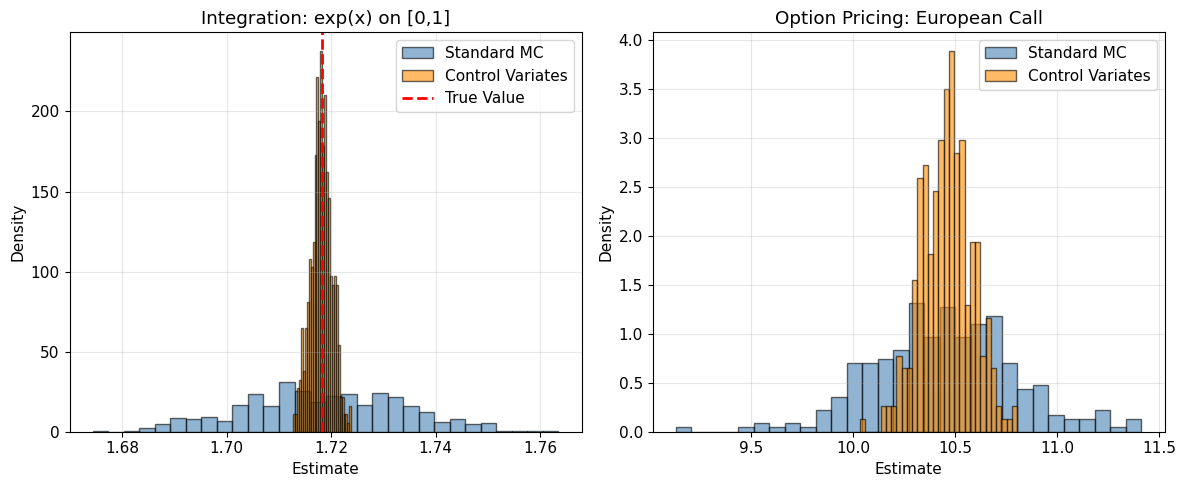

In [5]:
# --- Control Variates ---
# Integration: f(x) = exp(x), control g(x) = x, E[g] = 0.5

def mc_control_integral(f, g, mu_g, n, a=0.0, b=1.0):
    x = np.random.uniform(a, b, n)
    fx = f(x)
    gx = g(x)
    cov = np.cov(fx, gx, ddof=1)[0, 1]
    var_g = np.var(gx, ddof=1)
    beta = cov / var_g
    est = (b - a) * (np.mean(fx) - beta * (np.mean(gx) - mu_g))
    return est, beta

f_exp = lambda x: np.exp(x)
g_lin = lambda x: x
mu_g = 0.5
true_val = exp(1) - 1

n_trials = 500
n = 1000
est_std_int = [mc_standard_integral(f_exp, n) for _ in range(n_trials)]
est_cv_int = [mc_control_integral(f_exp, g_lin, mu_g, n)[0] for _ in range(n_trials)]

var_std_int = np.var(est_std_int, ddof=1)
var_cv_int = np.var(est_cv_int, ddof=1)

print("Control Variates for integral of exp(x) on [0,1]")
print("True value:        {:.6f}".format(true_val))
print("Standard var:      {:.6e}".format(var_std_int))
print("Control var:       {:.6e}".format(var_cv_int))
print("Reduction ratio:   {:.2f}x".format(var_std_int / var_cv_int))

# Option pricing with control variate
S0, K, T, r, sigma = 100.0, 100.0, 1.0, 0.05, 0.2

def call_standard(S0, K, T, r, sigma, n):
    Z = np.random.standard_normal(n)
    ST = S0 * np.exp((r - 0.5*sigma**2)*T + sigma*sqrt(T)*Z)
    payoff = np.maximum(ST - K, 0)
    disc_payoff = np.exp(-r*T) * payoff
    return disc_payoff

def call_control(S0, K, T, r, sigma, n):
    Z = np.random.standard_normal(n)
    ST = S0 * np.exp((r - 0.5*sigma**2)*T + sigma*sqrt(T)*Z)
    payoff = np.maximum(ST - K, 0)
    disc_payoff = np.exp(-r*T) * payoff
    disc_ST = np.exp(-r*T) * ST
    cov = np.cov(disc_payoff, disc_ST, ddof=1)[0, 1]
    var_ST = np.var(disc_ST, ddof=1)
    beta = cov / var_ST
    control_est = disc_payoff - beta * (disc_ST - S0)
    return control_est, beta

n_opt = 2000
n_runs = 300

est_std_opt = []
est_cv_opt = []
for _ in range(n_runs):
    payoffs = call_standard(S0, K, T, r, sigma, n_opt)
    est_std_opt.append(np.mean(payoffs))
    
    control_est, beta = call_control(S0, K, T, r, sigma, n_opt)
    est_cv_opt.append(np.mean(control_est))

var_std_opt = np.var(est_std_opt, ddof=1)
var_cv_opt = np.var(est_cv_opt, ddof=1)

print("\nControl Variates for European Call Option")
print("Standard var:      {:.6e}".format(var_std_opt))
print("Control var:       {:.6e}".format(var_cv_opt))
print("Reduction ratio:   {:.2f}x".format(var_std_opt / var_cv_opt))

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(est_std_int, bins=30, density=True, alpha=0.6, color='steelblue', edgecolor='black', label='Standard MC')
axes[0].hist(est_cv_int, bins=30, density=True, alpha=0.6, color='darkorange', edgecolor='black', label='Control Variates')
axes[0].axvline(true_val, color='red', linestyle='--', lw=2, label='True Value')
axes[0].set_title('Integration: exp(x) on [0,1]')
axes[0].set_xlabel('Estimate')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(est_std_opt, bins=30, density=True, alpha=0.6, color='steelblue', edgecolor='black', label='Standard MC')
axes[1].hist(est_cv_opt, bins=30, density=True, alpha=0.6, color='darkorange', edgecolor='black', label='Control Variates')
axes[1].set_title('Option Pricing: European Call')
axes[1].set_xlabel('Estimate')
axes[1].set_ylabel('Density')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Head-to-Head Comparison

We now apply all three variance reduction techniques to the same challenging problem: estimating a deep out-of-the-money (OTM) European call option. In this scenario the payoff is zero most of the time, making standard MC highly inefficient.

- **Standard MC**: most samples land below the strike and are wasted
- **Antithetic**: moderate improvement via negative correlation
- **Importance Sampling**: shifts the sampling density toward the strike region
- **Control Variates**: uses the known expectation of the discounted stock price

We measure efficiency via the **variance reduction ratio**:

$$\text{Ratio} = \frac{\text{Var}(\hat{I}_{\text{std}})}{\text{Var}(\hat{I}_{\text{reduced}})}$$


OTM Call Option (S0=100, K=120) - Variance Reduction Comparison
------------------------------------------------------------
Method                       Mean          Std    Var Ratio
------------------------------------------------------------
Standard                   3.2477       0.1216          1.0x
Antithetic                 3.2559       0.1175          1.1x
Importance Sampling        3.2454       0.0332         13.4x
Control Variates           3.2531       0.0802          2.3x


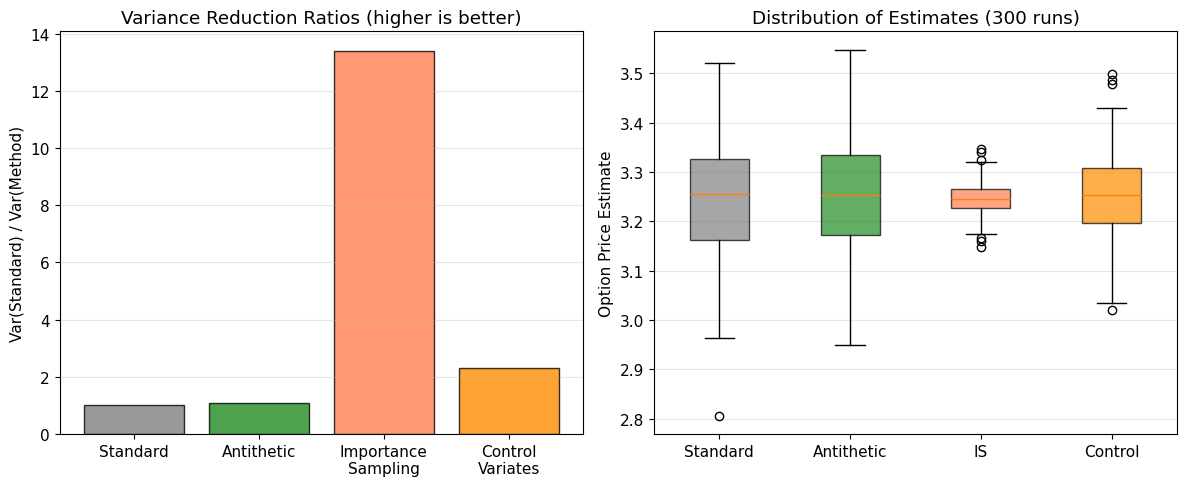

In [8]:
# --- Combined comparison on OTM option ---
S0, K, T, r, sigma = 100.0, 120.0, 1.0, 0.05, 0.2
n = 5000
n_runs = 300

def option_standard_otm(n):
    Z = np.random.standard_normal(n)
    ST = S0 * np.exp((r - 0.5*sigma**2)*T + sigma*sqrt(T)*Z)
    payoff = np.maximum(ST - K, 0)
    return np.exp(-r*T) * np.mean(payoff)

def option_antithetic_otm(n):
    n = n // 2
    Z = np.random.standard_normal(n)
    ST1 = S0 * np.exp((r - 0.5*sigma**2)*T + sigma*sqrt(T)*Z)
    ST2 = S0 * np.exp((r - 0.5*sigma**2)*T + sigma*sqrt(T)*(-Z))
    p1 = np.maximum(ST1 - K, 0)
    p2 = np.maximum(ST2 - K, 0)
    return np.exp(-r*T) * np.mean(0.5*(p1 + p2))

def option_is_otm(n, mu=1.5):
    Y = np.random.normal(mu, 1.0, n)
    ST = S0 * np.exp((r - 0.5*sigma**2)*T + sigma*sqrt(T)*Y)
    payoff = np.maximum(ST - K, 0)
    weights = np.exp(0.5*mu**2 - mu*Y)
    return np.exp(-r*T) * np.mean(payoff * weights)

def option_cv_otm(n):
    Z = np.random.standard_normal(n)
    ST = S0 * np.exp((r - 0.5*sigma**2)*T + sigma*sqrt(T)*Z)
    payoff = np.maximum(ST - K, 0)
    disc_payoff = np.exp(-r*T) * payoff
    disc_ST = np.exp(-r*T) * ST
    cov = np.cov(disc_payoff, disc_ST, ddof=1)[0, 1]
    var_ST = np.var(disc_ST, ddof=1)
    beta = cov / var_ST
    return np.mean(disc_payoff - beta * (disc_ST - S0))

est_std = [option_standard_otm(n) for _ in range(n_runs)]
est_anti = [option_antithetic_otm(n) for _ in range(n_runs)]
est_is = [option_is_otm(n) for _ in range(n_runs)]
est_cv = [option_cv_otm(n) for _ in range(n_runs)]

var_std = np.var(est_std, ddof=1)
var_anti = np.var(est_anti, ddof=1)
var_is = np.var(est_is, ddof=1)
var_cv = np.var(est_cv, ddof=1)

ratios = {
    'Standard': 1.0,
    'Antithetic': var_std / var_anti,
    'Importance\nSampling': var_std / var_is,
    'Control\nVariates': var_std / var_cv
}

print("OTM Call Option (S0=100, K=120) - Variance Reduction Comparison")
print("-" * 60)
print("{:<20} {:>12} {:>12} {:>12}".format('Method', 'Mean', 'Std', 'Var Ratio'))
print("-" * 60)
print("{:<20} {:>12.4f} {:>12.4f} {:>12.1f}x".format('Standard', np.mean(est_std), np.sqrt(var_std), ratios['Standard']))
print("{:<20} {:>12.4f} {:>12.4f} {:>12.1f}x".format('Antithetic', np.mean(est_anti), np.sqrt(var_anti), ratios['Antithetic']))
print("{:<20} {:>12.4f} {:>12.4f} {:>12.1f}x".format('Importance Sampling', np.mean(est_is), np.sqrt(var_is), ratios['Importance\nSampling']))
print("{:<20} {:>12.4f} {:>12.4f} {:>12.1f}x".format('Control Variates', np.mean(est_cv), np.sqrt(var_cv), ratios['Control\nVariates']))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

methods = list(ratios.keys())
values = list(ratios.values())
colors = ['gray', 'forestgreen', 'coral', 'darkorange']

axes[0].bar(methods, values, color=colors, edgecolor='black', alpha=0.8)
axes[0].set_title('Variance Reduction Ratios (higher is better)')
axes[0].set_ylabel('Var(Standard) / Var(Method)')
axes[0].grid(True, alpha=0.3, axis='y')

data = [est_std, est_anti, est_is, est_cv]
bp = axes[1].boxplot(data, tick_labels=['Standard', 'Antithetic', 'IS', 'Control'], patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title('Distribution of Estimates ({} runs)'.format(n_runs))
axes[1].set_ylabel('Option Price Estimate')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


## 5. Practical Guidance & When to Use Each Technique

| Technique | Best For | Requirements | Typical Gain |
|-----------|----------|--------------|------------|
| **Antithetic Variates** | Monotone integrands, symmetric distributions | Easy to generate negative pairs | 2-10x |
| **Importance Sampling** | Rare events, tail probabilities, deep OTM options | Good proposal density $q(x)$ | 10-1000x |
| **Control Variates** | Problems with known approximate solutions | Correlated variable with known mean | 5-50x |

### Key Insights
- **Antithetic** is the easiest to implement and always worth trying first.
- **Importance Sampling** requires domain knowledge to design $q(x)$ but can yield massive reductions for rare events.
- **Control Variates** are extremely powerful when a good proxy model exists (e.g., Black-Scholes price as control for exotic options).

### Combined Techniques
These methods are not mutually exclusive. For example, one can use **antithetic variates** together with **control variates** in the same simulation, compounding the variance reduction.


Combined Antithetic + Control Variates
Variance:          2.702017e-04
vs Standard:       60.1x reduction
vs Antithetic:     44.6x reduction
vs Control:        24.7x reduction


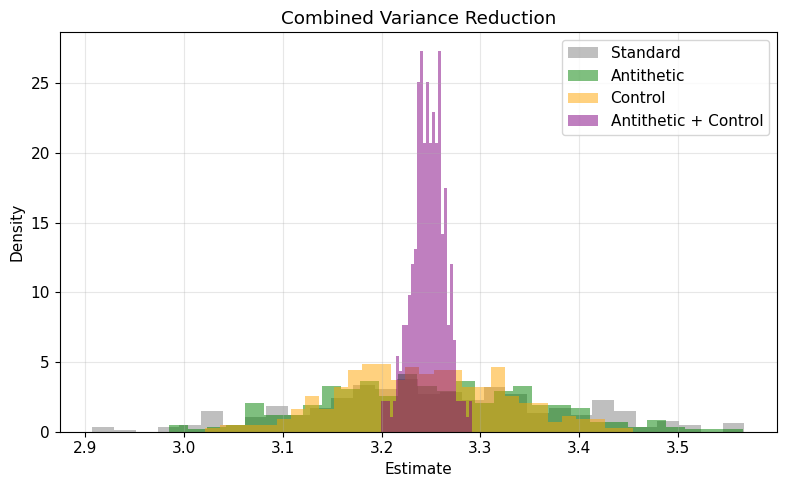

In [7]:
# --- Demonstrating combined techniques ---
# Antithetic + Control Variates together

def option_combined(n):
    n = n // 2
    Z = np.random.standard_normal(n)
    ST1 = S0 * np.exp((r - 0.5*sigma**2)*T + sigma*sqrt(T)*Z)
    ST2 = S0 * np.exp((r - 0.5*sigma**2)*T + sigma*sqrt(T)*(-Z))
    p1 = np.maximum(ST1 - K, 0)
    p2 = np.maximum(ST2 - K, 0)
    avg_p = 0.5 * (p1 + p2)
    disc_p = np.exp(-r*T) * avg_p
    disc_ST = 0.5 * np.exp(-r*T) * (ST1 + ST2)
    cov = np.cov(disc_p, disc_ST, ddof=1)[0, 1]
    var_ST = np.var(disc_ST, ddof=1)
    beta = cov / var_ST
    return np.mean(disc_p - beta * (disc_ST - S0))

est_combined = [option_combined(n) for _ in range(n_runs)]
var_combined = np.var(est_combined, ddof=1)

print("Combined Antithetic + Control Variates")
print("Variance:          {:.6e}".format(var_combined))
print("vs Standard:       {:.1f}x reduction".format(var_std / var_combined))
print("vs Antithetic:     {:.1f}x reduction".format(var_anti / var_combined))
print("vs Control:        {:.1f}x reduction".format(var_cv / var_combined))

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(est_std, bins=30, density=True, alpha=0.5, color='gray', label='Standard')
ax.hist(est_anti, bins=30, density=True, alpha=0.5, color='green', label='Antithetic')
ax.hist(est_cv, bins=30, density=True, alpha=0.5, color='orange', label='Control')
ax.hist(est_combined, bins=30, density=True, alpha=0.5, color='purple', label='Antithetic + Control')
ax.set_title('Combined Variance Reduction')
ax.set_xlabel('Estimate')
ax.set_ylabel('Density')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Summary

Variance reduction is the art of extracting more information per random sample. The three techniques covered here address different sources of inefficiency:

1. **Antithetic Variates** reduce variance by exploiting symmetry and negative correlation.
2. **Importance Sampling** reweights samples to focus computational effort where it matters most.
3. **Control Variates** borrow strength from a related problem with a known analytical solution.

Because Monte Carlo error decays only as $O(N^{-1/2})$, a 100x variance reduction is equivalent to running 10,000x more simulations. Mastering these techniques is essential for practical simulation in quantitative finance, physics, and engineering.
